In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

In [2]:
digits = load_digits()

X = digits.data
y = digits.target


print(f"X Shape is {X.shape}")
print(f"y Shape is {y.shape}")


X Shape is (1797, 64)
y Shape is (1797,)


In [3]:
def train_test_split(X,y,test_size=0.2,random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
        
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    
    test_count = int(X.shape[0]*test_size)
    
    test_indx = indices[:test_count]
    train_indx = indices[test_count:]
    
    return X[train_indx] , X[test_indx] , y[train_indx] , y[test_indx]



In [4]:
def normalized_data(X):
    X_normalized = X / X.max()
    return X_normalized

X = normalized_data(X)

print(f'Min X {X.min()}')
print(f'Max X {X.max()}')
    

Min X 0.0
Max X 1.0


In [5]:
X_train , X_test , y_train , y_test  = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Training set is : {X_train.shape}")
print(f"Testing set is : {X_test.shape}")
print(f"label training is : {y_train.shape}")
print(f"y_test (target) is : {y_test.shape}")

Training set is : (1438, 64)
Testing set is : (359, 64)
label training is : (1438,)
y_test (target) is : (359,)


In [6]:
def relu(Z):
    return np.maximum(0,Z)


def softmax(Z):
    exp_z = np.exp(Z-np.max(Z,axis=1,keepdims=True))
    return exp_z / np.sum(exp_z,axis=1 , keepdims = True)


In [7]:
def cross_entropy(y_true,y_pred):
    epsilon = 1e-8
    y_pred = np.clip(y_pred,epsilon,1-epsilon)
    loss = -np.mean(np.sum(y_true*np.log(y_pred),axis=1))
    return loss



In [8]:
def onehot_encoding(y,num_classes=10):
    one_hot = np.zeros((len(y),num_classes))
    one_hot[np.arange(len(y)),y] = 1
    return one_hot

In [ ]:
def train(X_train, y_train, epochs=1000, learning_rate=0.1):
    input_size = X_train.shape[1]
    hidden_size = 128
    output_size = 10
    m = X_train.shape[0]

    w1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))

    w2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))

    y_train_encoded = onehot_encoding(y_train)

    accuracy_history = []

    for epoch in range(epochs):

        
        neto1 = X_train @ w1 + b1
        A1 = relu(neto1)

        neto2 = A1 @ w2 + b2
        A2 = softmax(neto2)

        loss = cross_entropy(y_train_encoded, A2)

        dZ2 = A2 - y_train_encoded

        dW2 = (A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2 @ w2.T
        dZ1 = dA1 * (neto1 > 0)

        dW1 = (X_train.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

      
        w2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        w1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        predictions = np.argmax(A2, axis=1)
        actual = np.argmax(y_train_encoded, axis=1)

        accuracy = np.mean(predictions == actual)
        accuracy_history.append(accuracy)

        if epoch % 10 == 0:
            print(
                f"Epoch: {epoch}, "
                f"Loss: {loss:.4f}, "
                f"Accuracy: {accuracy:.4f}"
            )

    return w1, b1, w2, b2, accuracy_history

In [16]:
w1, b1, w2, b2, accuracy_history = train(
    X_train,
    y_train
)

Epoch: 0, Loss: 2.3024, Accuracy: 0.1280
Epoch: 10, Loss: 2.2999, Accuracy: 0.1078
Epoch: 20, Loss: 2.2971, Accuracy: 0.1078
Epoch: 30, Loss: 2.2934, Accuracy: 0.1203
Epoch: 40, Loss: 2.2885, Accuracy: 0.1919
Epoch: 50, Loss: 2.2817, Accuracy: 0.2538
Epoch: 60, Loss: 2.2723, Accuracy: 0.3067
Epoch: 70, Loss: 2.2589, Accuracy: 0.3901
Epoch: 80, Loss: 2.2398, Accuracy: 0.4604
Epoch: 90, Loss: 2.2129, Accuracy: 0.5070
Epoch: 100, Loss: 2.1752, Accuracy: 0.5355
Epoch: 110, Loss: 2.1235, Accuracy: 0.5758
Epoch: 120, Loss: 2.0547, Accuracy: 0.6057
Epoch: 130, Loss: 1.9668, Accuracy: 0.6287
Epoch: 140, Loss: 1.8605, Accuracy: 0.6481
Epoch: 150, Loss: 1.7397, Accuracy: 0.6662
Epoch: 160, Loss: 1.6110, Accuracy: 0.6766
Epoch: 170, Loss: 1.4814, Accuracy: 0.7010
Epoch: 180, Loss: 1.3567, Accuracy: 0.7385
Epoch: 190, Loss: 1.2407, Accuracy: 0.7726
Epoch: 200, Loss: 1.1350, Accuracy: 0.7949
Epoch: 210, Loss: 1.0403, Accuracy: 0.8164
Epoch: 220, Loss: 0.9559, Accuracy: 0.8401
Epoch: 230, Loss: 0.88

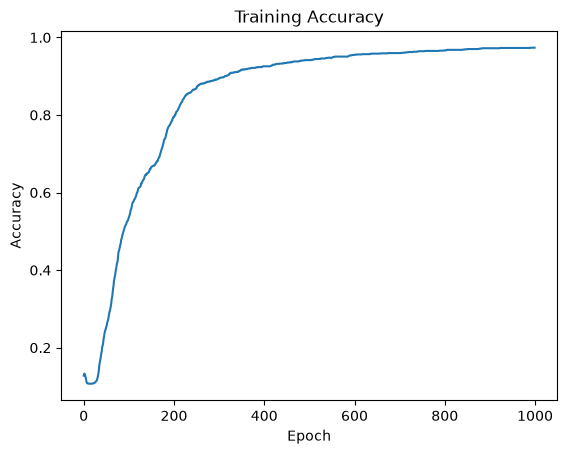

In [17]:
import matplotlib.pyplot as plt

plt.plot(accuracy_history)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

In [11]:
sample = X_test[0]
actual = y_test[0]

In [12]:
def predict(X, w1, b1, w2, b2):
    Z1 = X @ w1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ w2 + b2
    A2 = softmax(Z2)
    prediction = np.argmax(A2, axis=1)

    return prediction

In [18]:
prediction = predict(
    sample.reshape(1, -1),
    w1, b1, w2, b2
)

print("Actual:", actual)
print("Predicted:", prediction[0])

Actual: 6
Predicted: 6


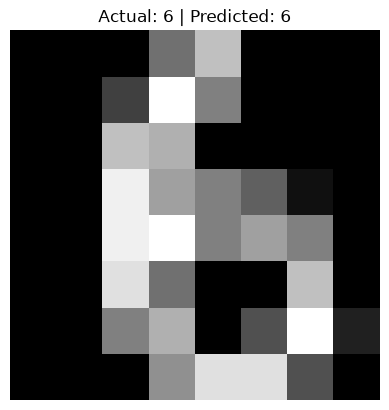

In [14]:
plt.imshow(X_test[0].reshape(8, 8), cmap="gray")
plt.title(f"Actual: {y_test[0]} | Predicted: {pred[0]}")
plt.axis("off")
plt.show()